## AGN FINAL PROJECT 
### Sona Davis
## TASK 3:
Using the quasar composite spectra from the SDSS survey (Vanden Berk et al. 2001) **estimate
the approximate contribution of the broad emission line emission to the six LSST bands
(ugrizy) at the following redshifts 0.5, 1.0, 1.5, 2.0, 2.5, 3.0**, assuming that the underlying
continuum is best described with the broken power-law (see Vanden Berk et al. 2001). In
addition, **consider the contribution of the strong emission lines (i.e. Lyα 1216, C IV 1549, C III]
1909, Mg II 2798, Hβ 4861, Hα 6563) to each of the six LSST bands (ugrizy)**. Describe in details
the used methodology. Useful tip: make use of the PhotoRM and fantasy notebook.

In [1]:
import sys
print(sys.version)

3.10.19 (main, Oct 10 2025, 08:52:10) [GCC 13.3.0]


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)

import numpy as np
import pandas as pd

import glob

In [3]:
from fantasy_agn.tools import read_sdss, read_text, read_gama_fits

# Below command import the necessary commands, which will be described later
from fantasy_agn.models import create_input_folder

from fantasy_agn.models import create_feii_model, create_model, create_tied_model, continuum, create_line, create_fixed_model

In [5]:
s=read_text('z05.txt')

In [6]:
s

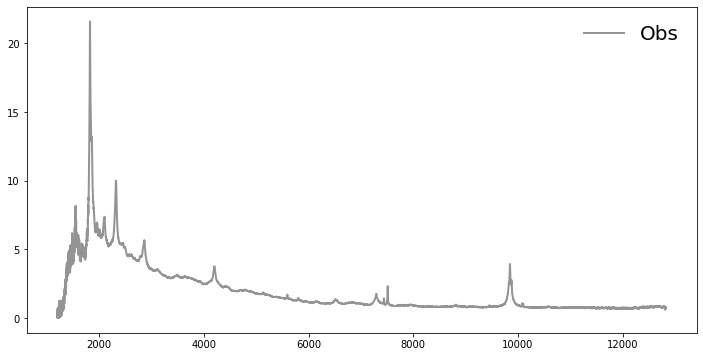

In [7]:
#Let's plot the spectrum for visual inspection.

plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(12,6))
plt.plot(s.wave, s.flux, color="#929591", label='Obs', lw=2)
plt.legend(loc='upper right',  prop={'size': 20}, frameon=False, ncol=2)

# It is obvious, e.g. based on the strong blue continuum and absence of absorption line, that the stellar contribution
# from the host galaxy can be negligible.

In [8]:
s.ra=29.519807539582 #example input of arbitrary rightascension
s.dec=-0.872742349310271 #example input of arbitrary declination
s.DeRedden()

In [9]:
s.z=0.5 #example input of arbitrary redshift
s.CorRed()

In [10]:
s.flux=s.flux*10

In [11]:
create_input_folder(xmin=4000,xmax=8000, path_to_folder='liness/')

Directory  liness/  Created 


In [12]:
cont=continuum(s,min_refer=5690, refer=5700, max_refer=5710)
broad=create_fixed_model(['hydrogen.csv'], name='br' )
he=create_fixed_model(['helium.csv'], name='he',fwhm=3000, min_fwhm=1000, max_fwhm=5000)
narrow=create_tied_model(name='OIII5007',files=['narrow_basic.csv','hydrogen.csv'],prefix='nr', fwhm=1000,min_offset=0, max_offset=300, min_fwhm=900, max_fwhm=1200,fix_oiii_ratio=True, position=5006.803341, included=True,min_amplitude=0.2)
#fe=create_feii_model(name='feii', fwhm=1800, min_fwhm=1000, max_fwhm=2000, offset=0, min_offset=-3000, max_offset=3000)
#fe.amp_b4p.min=10 #An example how to force the amplitude of a selected FeII multiplet.

In [13]:
s.crop(3200, 7700)
print(s.wave) # simple examine of the wavelength range

[3200.5 3201.5 3202.5 ... 7697.5 7698.5 7699.5]


In [14]:
model = cont+broad+narrow+he

In [15]:
s.fit(model, ntrial=2)

iteration:  1
iteration:  2


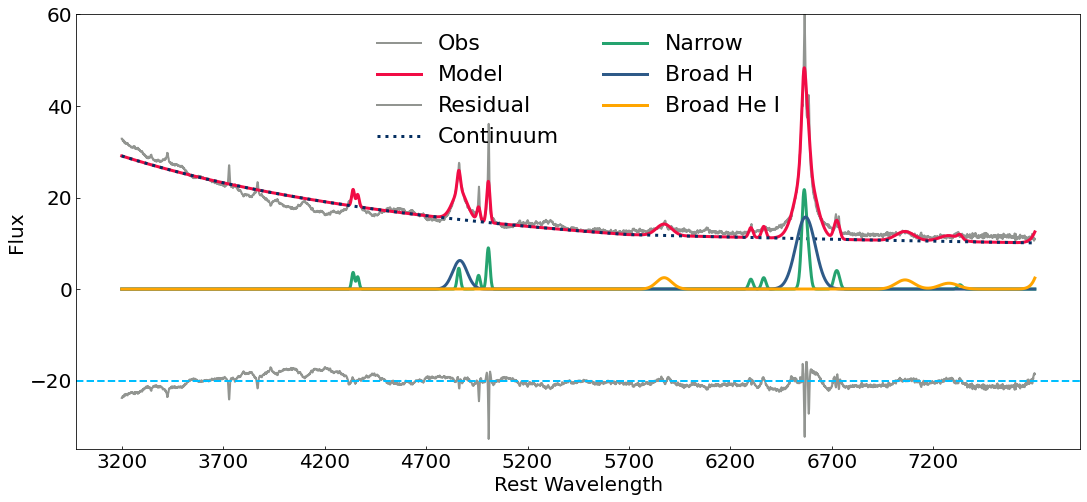

In [16]:
plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(s.wave, s.flux, color="#929591", label='Obs', lw=2)
plt.plot(s.wave, model(s.wave), color="#F10C45",label='Model',lw=3)
plt.plot(s.wave, model(s.wave)-s.flux-20, '-',color="#929591", label='Residual', lw=2)
plt.axhline(y=-20, color='deepskyblue', linestyle='--', lw=2)

plt.plot(s.wave, cont(s.wave),':',color="#042E60",label='Continuum', lw=3)
plt.plot(s.wave, narrow(s.wave),label='Narrow',color="#25A36F",lw=3)
plt.plot(s.wave, broad(s.wave), label='Broad H', lw=3, color="#2E5A88")
plt.plot(s.wave, he(s.wave), label='Broad He I', lw=3, color="orange")
#plt.plot(s.wave, fe(s.wave),'-',color="#CB416B",label='Fe II model', lw=3)

plt.xlabel('Rest Wavelength',fontsize=20)
plt.ylabel('Flux',fontsize=20)
#plt.xlim(3200, 7700)
plt.ylim(-35,60)
plt.tick_params(which='both', direction="in")
plt.yticks(fontsize=20)
plt.xticks(np.arange(3200, 7700, step=500),fontsize=20)
plt.legend(loc='upper center',  prop={'size': 22}, frameon=False, ncol=2)

#plt.savefig('fantasy_fit.pdf')

In [17]:
# Integrate total broad model,
flux_broad=np.sum(broad(s.wave))
print("Broad emission line total flux=",flux_broad)

# Mask the wavelength range of interess (e.g. Ha line) and integrate broad component.
x=s.wave
mask_ha=(x>6300)&(x<6700)
Ha_broad=np.sum(broad(s.wave)[mask_ha])
print("Ha_broad=",Ha_broad)

Broad emission line total flux= 2443.108543885046
Ha_broad= 1881.970556504676


# z = 1.0:

In [19]:
s=read_text('z10.txt')
s.ra=29.519807539582 #example input of arbitrary rightascension
s.dec=-0.872742349310271 #example input of arbitrary declination
s.DeRedden()
s.z=1 #example input of arbitrary redshift
s.CorRed()
s.flux=s.flux*10
cont=continuum(s,min_refer=5690, refer=5700, max_refer=5710)
broad=create_fixed_model(['hydrogen.csv'], name='br' )
he=create_fixed_model(['helium.csv'], name='he',fwhm=3000, min_fwhm=1000, max_fwhm=5000)
narrow=create_tied_model(name='OIII5007',files=['narrow_basic.csv','hydrogen.csv'],prefix='nr', fwhm=1000,min_offset=0, max_offset=300, min_fwhm=900, max_fwhm=1200,fix_oiii_ratio=True, position=5006.803341, included=True,min_amplitude=0.2)
#fe=create_feii_model(name='feii', fwhm=1800, min_fwhm=1000, max_fwhm=2000, offset=0, min_offset=-3000, max_offset=3000)
#fe.amp_b4p.min=10 #An example how to force the amplitude of a selected FeII multiplet.
s.crop(3200, 7700)
model = cont+broad+narrow+he
s.fit(model, ntrial=2)

iteration:  1
iteration:  2


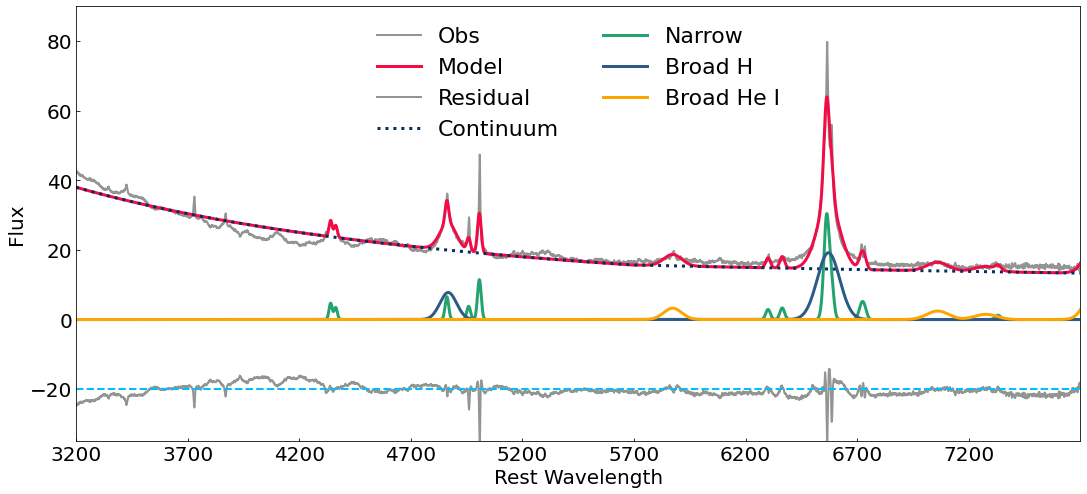

In [20]:
plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(s.wave, s.flux, color="#929591", label='Obs', lw=2)
plt.plot(s.wave, model(s.wave), color="#F10C45",label='Model',lw=3)
plt.plot(s.wave, model(s.wave)-s.flux-20, '-',color="#929591", label='Residual', lw=2)
plt.axhline(y=-20, color='deepskyblue', linestyle='--', lw=2)

plt.plot(s.wave, cont(s.wave),':',color="#042E60",label='Continuum', lw=3)
plt.plot(s.wave, narrow(s.wave),label='Narrow',color="#25A36F",lw=3)
plt.plot(s.wave, broad(s.wave), label='Broad H', lw=3, color="#2E5A88")
plt.plot(s.wave, he(s.wave), label='Broad He I', lw=3, color="orange")
#plt.plot(s.wave, fe(s.wave),'-',color="#CB416B",label='Fe II model', lw=3)

plt.xlabel('Rest Wavelength',fontsize=20)
plt.ylabel('Flux',fontsize=20)
plt.xlim(3200, 7700)
plt.ylim(-35,90)
plt.tick_params(which='both', direction="in")
plt.yticks(fontsize=20)
plt.xticks(np.arange(3200, 7700, step=500),fontsize=20)
plt.legend(loc='upper center',  prop={'size': 22}, frameon=False, ncol=2)

plt.savefig('fantasy_fitz10.png', bbox_inches='tight', pad_inches=0.1, transparent=True)

In [21]:
# Integrate total broad model,
flux_broad=np.sum(broad(s.wave))
print("Broad emission line total flux=",flux_broad)

# Mask the wavelength range of interess (e.g. Ha line) and integrate broad component.
x=s.wave
mask_ha=(x>6300)&(x<6700)
Ha_broad=np.sum(broad(s.wave)[mask_ha])
print("Ha_broad=",Ha_broad)

Broad emission line total flux= 3146.1292287010738
Ha_broad= 2407.7087086507636


# z = 1.5:

In [22]:
s=read_text('z15.txt')
s.ra=29.519807539582 #example input of arbitrary rightascension
s.dec=-0.872742349310271 #example input of arbitrary declination
s.DeRedden()
s.z=1.5 #example input of arbitrary redshift
s.CorRed()
s.flux=s.flux*10
cont=continuum(s,min_refer=5690, refer=5700, max_refer=5710)
broad=create_fixed_model(['hydrogen.csv'], name='br' )
he=create_fixed_model(['helium.csv'], name='he',fwhm=3000, min_fwhm=1000, max_fwhm=5000)
narrow=create_tied_model(name='OIII5007',files=['narrow_basic.csv','hydrogen.csv'],prefix='nr', fwhm=1000,min_offset=0, max_offset=300, min_fwhm=900, max_fwhm=1200,fix_oiii_ratio=True, position=5006.803341, included=True,min_amplitude=0.2)
#fe=create_feii_model(name='feii', fwhm=1800, min_fwhm=1000, max_fwhm=2000, offset=0, min_offset=-3000, max_offset=3000)
#fe.amp_b4p.min=10 #An example how to force the amplitude of a selected FeII multiplet.
s.crop(3200, 7700)
model = cont+broad+narrow+he
s.fit(model, ntrial=2)

iteration:  1
iteration:  2


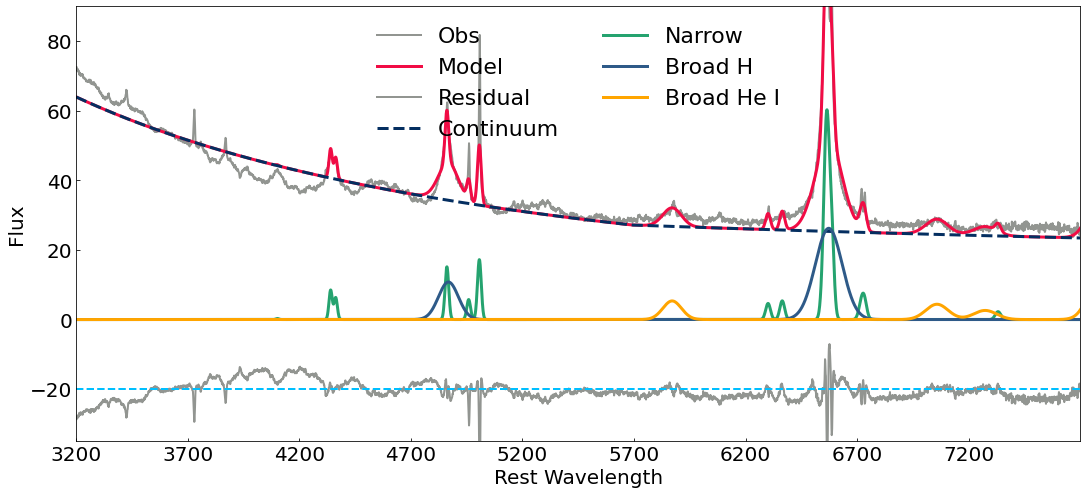

In [38]:
plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(s.wave, s.flux, color="#929591", label='Obs', lw=2)
plt.plot(s.wave, model(s.wave), color="#F10C45",label='Model',lw=3)
plt.plot(s.wave, model(s.wave)-s.flux-20, '-',color="#929591", label='Residual', lw=2)
plt.axhline(y=-20, color='deepskyblue', linestyle='--', lw=2)

plt.plot(s.wave, cont(s.wave),'--',color="#042E60",label='Continuum', lw=3)
plt.plot(s.wave, narrow(s.wave),label='Narrow',color="#25A36F",lw=3)
plt.plot(s.wave, broad(s.wave), label='Broad H', lw=3, color="#2E5A88")
plt.plot(s.wave, he(s.wave), label='Broad He I', lw=3, color="orange")
#plt.plot(s.wave, fe(s.wave),'-',color="#CB416B",label='Fe II model', lw=3)

plt.xlabel('Rest Wavelength',fontsize=20)
plt.ylabel('Flux',fontsize=20)
plt.xlim(3200, 7700)
plt.ylim(-35,90)
plt.tick_params(which='both', direction="in")
plt.yticks(fontsize=20)
plt.xticks(np.arange(3200, 7700, step=500),fontsize=20)
plt.legend(loc='upper center',  prop={'size': 22}, frameon=False, ncol=2)

plt.savefig('fantasy_fit.pdf')

In [24]:
# Integrate total broad model,
flux_broad=np.sum(broad(s.wave))
print("Broad emission line total flux=",flux_broad)

# Mask the wavelength range of interess (e.g. Ha line) and integrate broad component.
x=s.wave
mask_ha=(x>6300)&(x<6700)
Ha_broad=np.sum(broad(s.wave)[mask_ha])
print("Ha_broad=",Ha_broad)

Broad emission line total flux= 3913.9446257221234
Ha_broad= 2999.9651799708868


In [25]:
# z = 2.0 

In [26]:
s=read_text('z20.txt')
s.ra=29.519807539582 #example input of arbitrary rightascension
s.dec=-0.872742349310271 #example input of arbitrary declination
s.DeRedden()
s.z=2 #example input of arbitrary redshift
s.CorRed()
s.flux=s.flux*10
cont=continuum(s,min_refer=5690, refer=5700, max_refer=5710)
broad=create_fixed_model(['hydrogen.csv'], name='br' )
he=create_fixed_model(['helium.csv'], name='he',fwhm=3000, min_fwhm=1000, max_fwhm=5000)
narrow=create_tied_model(name='OIII5007',files=['narrow_basic.csv','hydrogen.csv'],prefix='nr', fwhm=1000,min_offset=0, max_offset=300, min_fwhm=900, max_fwhm=1200,fix_oiii_ratio=True, position=5006.803341, included=True,min_amplitude=0.2)
#fe=create_feii_model(name='feii', fwhm=1800, min_fwhm=1000, max_fwhm=2000, offset=0, min_offset=-3000, max_offset=3000)
#fe.amp_b4p.min=10 #An example how to force the amplitude of a selected FeII multiplet.
s.crop(3200, 7700)
model = cont+broad+narrow+he
s.fit(model, ntrial=2)

iteration:  1
iteration:  2


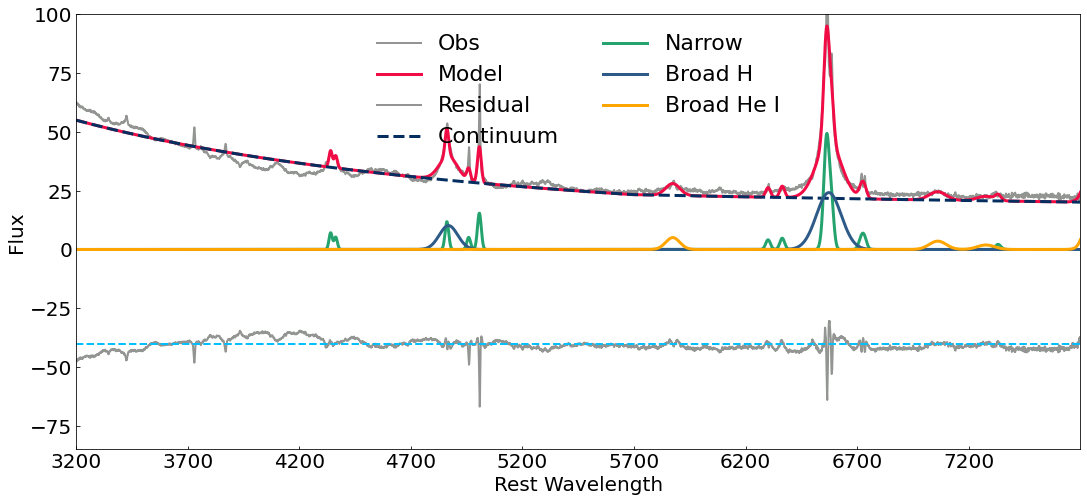

In [27]:
plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(s.wave, s.flux, color="#929591", label='Obs', lw=2)
plt.plot(s.wave, model(s.wave), color="#F10C45",label='Model',lw=3)
plt.plot(s.wave, model(s.wave)-s.flux-40, '-',color="#929591", label='Residual', lw=2)
plt.axhline(y=-40, color='deepskyblue', linestyle='--', lw=2)

plt.plot(s.wave, cont(s.wave),'--',color="#042E60",label='Continuum', lw=3)
plt.plot(s.wave, narrow(s.wave),label='Narrow',color="#25A36F",lw=3)
plt.plot(s.wave, broad(s.wave), label='Broad H', lw=3, color="#2E5A88")
plt.plot(s.wave, he(s.wave), label='Broad He I', lw=3, color="orange")
#plt.plot(s.wave, fe(s.wave),'-',color="#CB416B",label='Fe II model', lw=3)

plt.xlabel('Rest Wavelength',fontsize=20)
plt.ylabel('Flux',fontsize=20)
plt.xlim(3200, 7700)
plt.ylim(-85,100)
plt.tick_params(which='both', direction="in")
plt.yticks(fontsize=20)
plt.xticks(np.arange(3200, 7700, step=500),fontsize=20)
plt.legend(loc='upper center',  prop={'size': 22}, frameon=False, ncol=2)

#plt.savefig('fantasy_fit.pdf')

In [28]:
# Integrate total broad model,
flux_broad=np.sum(broad(s.wave))
print("Broad emission line total flux=",flux_broad)

# Mask the wavelength range of interess (e.g. Ha line) and integrate broad component.
x=s.wave
mask_ha=(x>6300)&(x<6700)
Ha_broad=np.sum(broad(s.wave)[mask_ha])
print("Ha_broad=",Ha_broad)

Broad emission line total flux= 4417.099556195824
Ha_broad= 3331.862987043813


In [29]:
# z = 2.5 

In [30]:
s=read_text('z25.txt')
s.ra=29.519807539582 #example input of arbitrary rightascension
s.dec=-0.872742349310271 #example input of arbitrary declination
s.DeRedden()
s.z=2.5 #example input of arbitrary redshift
s.CorRed()
s.flux=s.flux*10
cont=continuum(s,min_refer=5690, refer=5700, max_refer=5710)
broad=create_fixed_model(['hydrogen.csv'], name='br' )
he=create_fixed_model(['helium.csv'], name='he',fwhm=3000, min_fwhm=1000, max_fwhm=5000)
narrow=create_tied_model(name='OIII5007',files=['narrow_basic.csv','hydrogen.csv'],prefix='nr', fwhm=1000,min_offset=0, max_offset=300, min_fwhm=900, max_fwhm=1200,fix_oiii_ratio=True, position=5006.803341, included=True,min_amplitude=0.2)
#fe=create_feii_model(name='feii', fwhm=1800, min_fwhm=1000, max_fwhm=2000, offset=0, min_offset=-3000, max_offset=3000)
#fe.amp_b4p.min=10 #An example how to force the amplitude of a selected FeII multiplet.
s.crop(3200, 7700)
model = cont+broad+narrow+he
s.fit(model, ntrial=2)

iteration:  1
iteration:  2


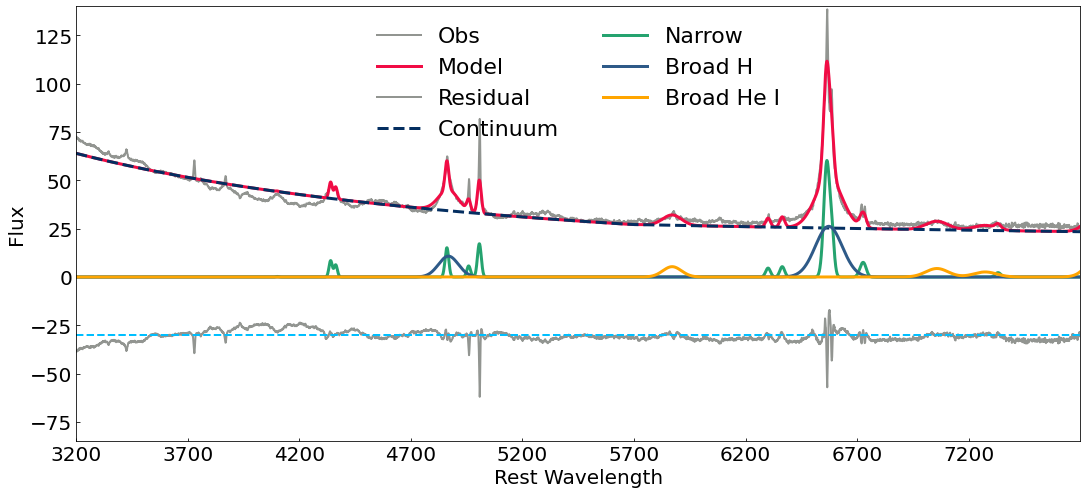

In [31]:
plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(s.wave, s.flux, color="#929591", label='Obs', lw=2)
plt.plot(s.wave, model(s.wave), color="#F10C45",label='Model',lw=3)
plt.plot(s.wave, model(s.wave)-s.flux-30, '-',color="#929591", label='Residual', lw=2)
plt.axhline(y=-30, color='deepskyblue', linestyle='--', lw=2)

plt.plot(s.wave, cont(s.wave),'--',color="#042E60",label='Continuum', lw=3)
plt.plot(s.wave, narrow(s.wave),label='Narrow',color="#25A36F",lw=3)
plt.plot(s.wave, broad(s.wave), label='Broad H', lw=3, color="#2E5A88")
plt.plot(s.wave, he(s.wave), label='Broad He I', lw=3, color="orange")
#plt.plot(s.wave, fe(s.wave),'-',color="#CB416B",label='Fe II model', lw=3)

plt.xlabel('Rest Wavelength',fontsize=20)
plt.ylabel('Flux',fontsize=20)
plt.xlim(3200, 7700)
plt.ylim(-85,140)
plt.tick_params(which='both', direction="in")
plt.yticks(fontsize=20)
plt.xticks(np.arange(3200, 7700, step=500),fontsize=20)
plt.legend(loc='upper center',  prop={'size': 22}, frameon=False, ncol=2)

#plt.savefig('fantasy_fit.pdf')

In [32]:
# Integrate total broad model,
flux_broad=np.sum(broad(s.wave))
print("Broad emission line total flux=",flux_broad)

# Mask the wavelength range of interess (e.g. Ha line) and integrate broad component.
x=s.wave
mask_ha=(x>6300)&(x<6700)
Ha_broad=np.sum(broad(s.wave)[mask_ha])
print("Ha_broad=",Ha_broad)

Broad emission line total flux= 5159.268388432725
Ha_broad= 3887.8671404983447


In [33]:
# z = 3.0 

In [34]:
s=read_text('z25.txt')
s.ra=29.519807539582 #example input of arbitrary rightascension
s.dec=-0.872742349310271 #example input of arbitrary declination
s.DeRedden()
s.z=2.5 #example input of arbitrary redshift
s.CorRed()
s.flux=s.flux*10
cont=continuum(s,min_refer=5690, refer=5700, max_refer=5710)
broad=create_fixed_model(['hydrogen.csv'], name='br' )
he=create_fixed_model(['helium.csv'], name='he',fwhm=3000, min_fwhm=1000, max_fwhm=5000)
narrow=create_tied_model(name='OIII5007',files=['narrow_basic.csv','hydrogen.csv'],prefix='nr', fwhm=1000,min_offset=0, max_offset=300, min_fwhm=900, max_fwhm=1200,fix_oiii_ratio=True, position=5006.803341, included=True,min_amplitude=0.2)
#fe=create_feii_model(name='feii', fwhm=1800, min_fwhm=1000, max_fwhm=2000, offset=0, min_offset=-3000, max_offset=3000)
#fe.amp_b4p.min=10 #An example how to force the amplitude of a selected FeII multiplet.
s.crop(3200, 7700)
model = cont+broad+narrow+he
s.fit(model, ntrial=2)

iteration:  1
iteration:  2


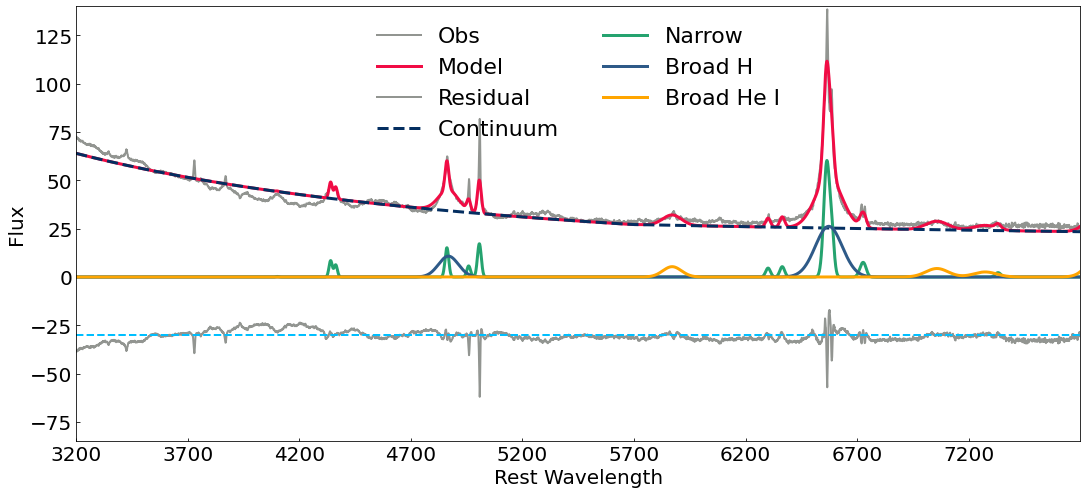

In [35]:
plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(s.wave, s.flux, color="#929591", label='Obs', lw=2)
plt.plot(s.wave, model(s.wave), color="#F10C45",label='Model',lw=3)
plt.plot(s.wave, model(s.wave)-s.flux-30, '-',color="#929591", label='Residual', lw=2)
plt.axhline(y=-30, color='deepskyblue', linestyle='--', lw=2)

plt.plot(s.wave, cont(s.wave),'--',color="#042E60",label='Continuum', lw=3)
plt.plot(s.wave, narrow(s.wave),label='Narrow',color="#25A36F",lw=3)
plt.plot(s.wave, broad(s.wave), label='Broad H', lw=3, color="#2E5A88")
plt.plot(s.wave, he(s.wave), label='Broad He I', lw=3, color="orange")
#plt.plot(s.wave, fe(s.wave),'-',color="#CB416B",label='Fe II model', lw=3)

plt.xlabel('Rest Wavelength',fontsize=20)
plt.ylabel('Flux',fontsize=20)
plt.xlim(3200, 7700)
plt.ylim(-85,140)
plt.tick_params(which='both', direction="in")
plt.yticks(fontsize=20)
plt.xticks(np.arange(3200, 7700, step=500),fontsize=20)
plt.legend(loc='upper center',  prop={'size': 22}, frameon=False, ncol=2)

#plt.savefig('fantasy_fit.pdf')

In [36]:
# Integrate total broad model,
flux_broad=np.sum(broad(s.wave))
print("Broad emission line total flux=",flux_broad)

# Mask the wavelength range of interess (e.g. Ha line) and integrate broad component.
x=s.wave
mask_ha=(x>6300)&(x<6700)
Ha_broad=np.sum(broad(s.wave)[mask_ha])
print("Ha_broad=",Ha_broad)

Broad emission line total flux= 5159.268388432725
Ha_broad= 3887.8671404983447


In [37]:
5159/2443

2.1117478510028653

To estimate the contribution of broad emission lines, the FANTASY
package was utilised to model the composite quasar spectrum .
A synthetic spectrum was generated to best fit the observed data displaying both the modeled and observed
spectra, along with their residual, confirming a good fit. The implementation of FANTASY was applied across all six redshift cases.The contribution of the broad emission lines was quantified by integrating the area under each emission
feature relative to the continuum. This contribution was found to
increase with redshift, with the 𝑧 = 3 case showing a broad line contribution 2.11 times that of the z=0.5 case.